## llama 参数
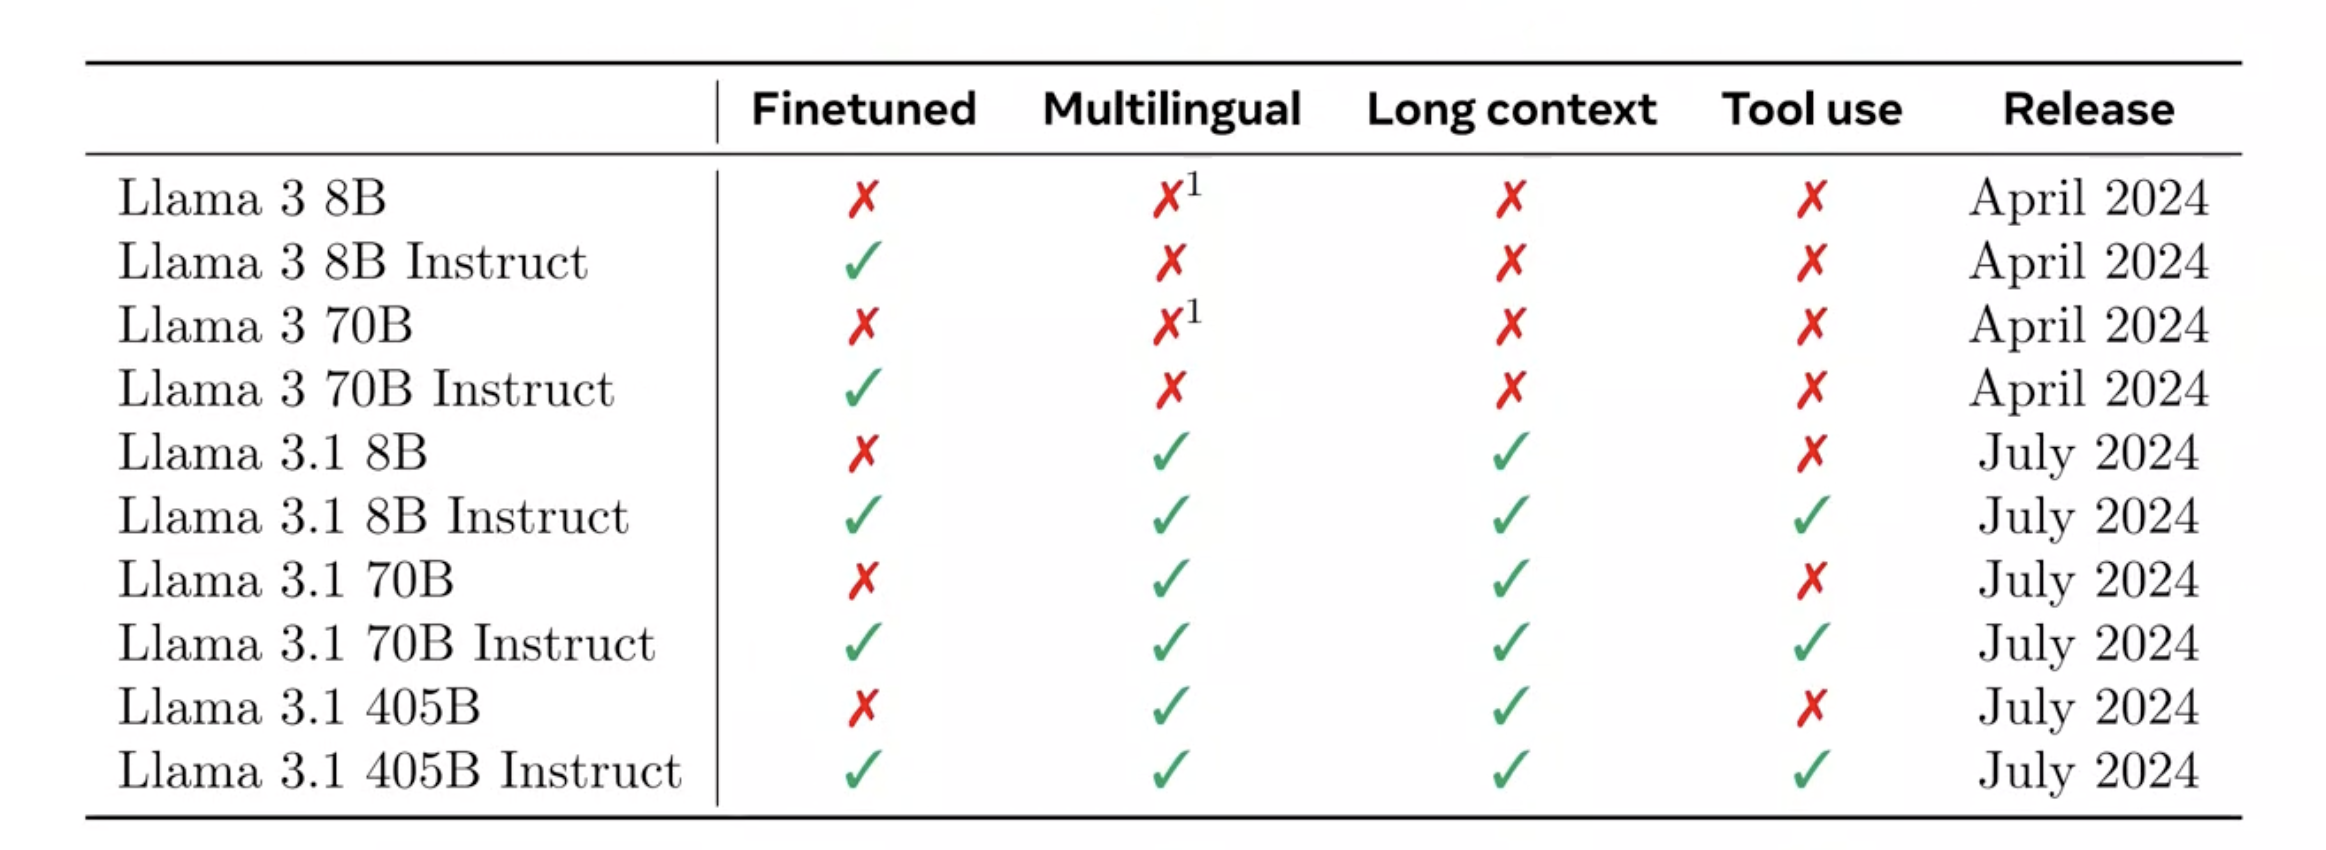

## 跑分
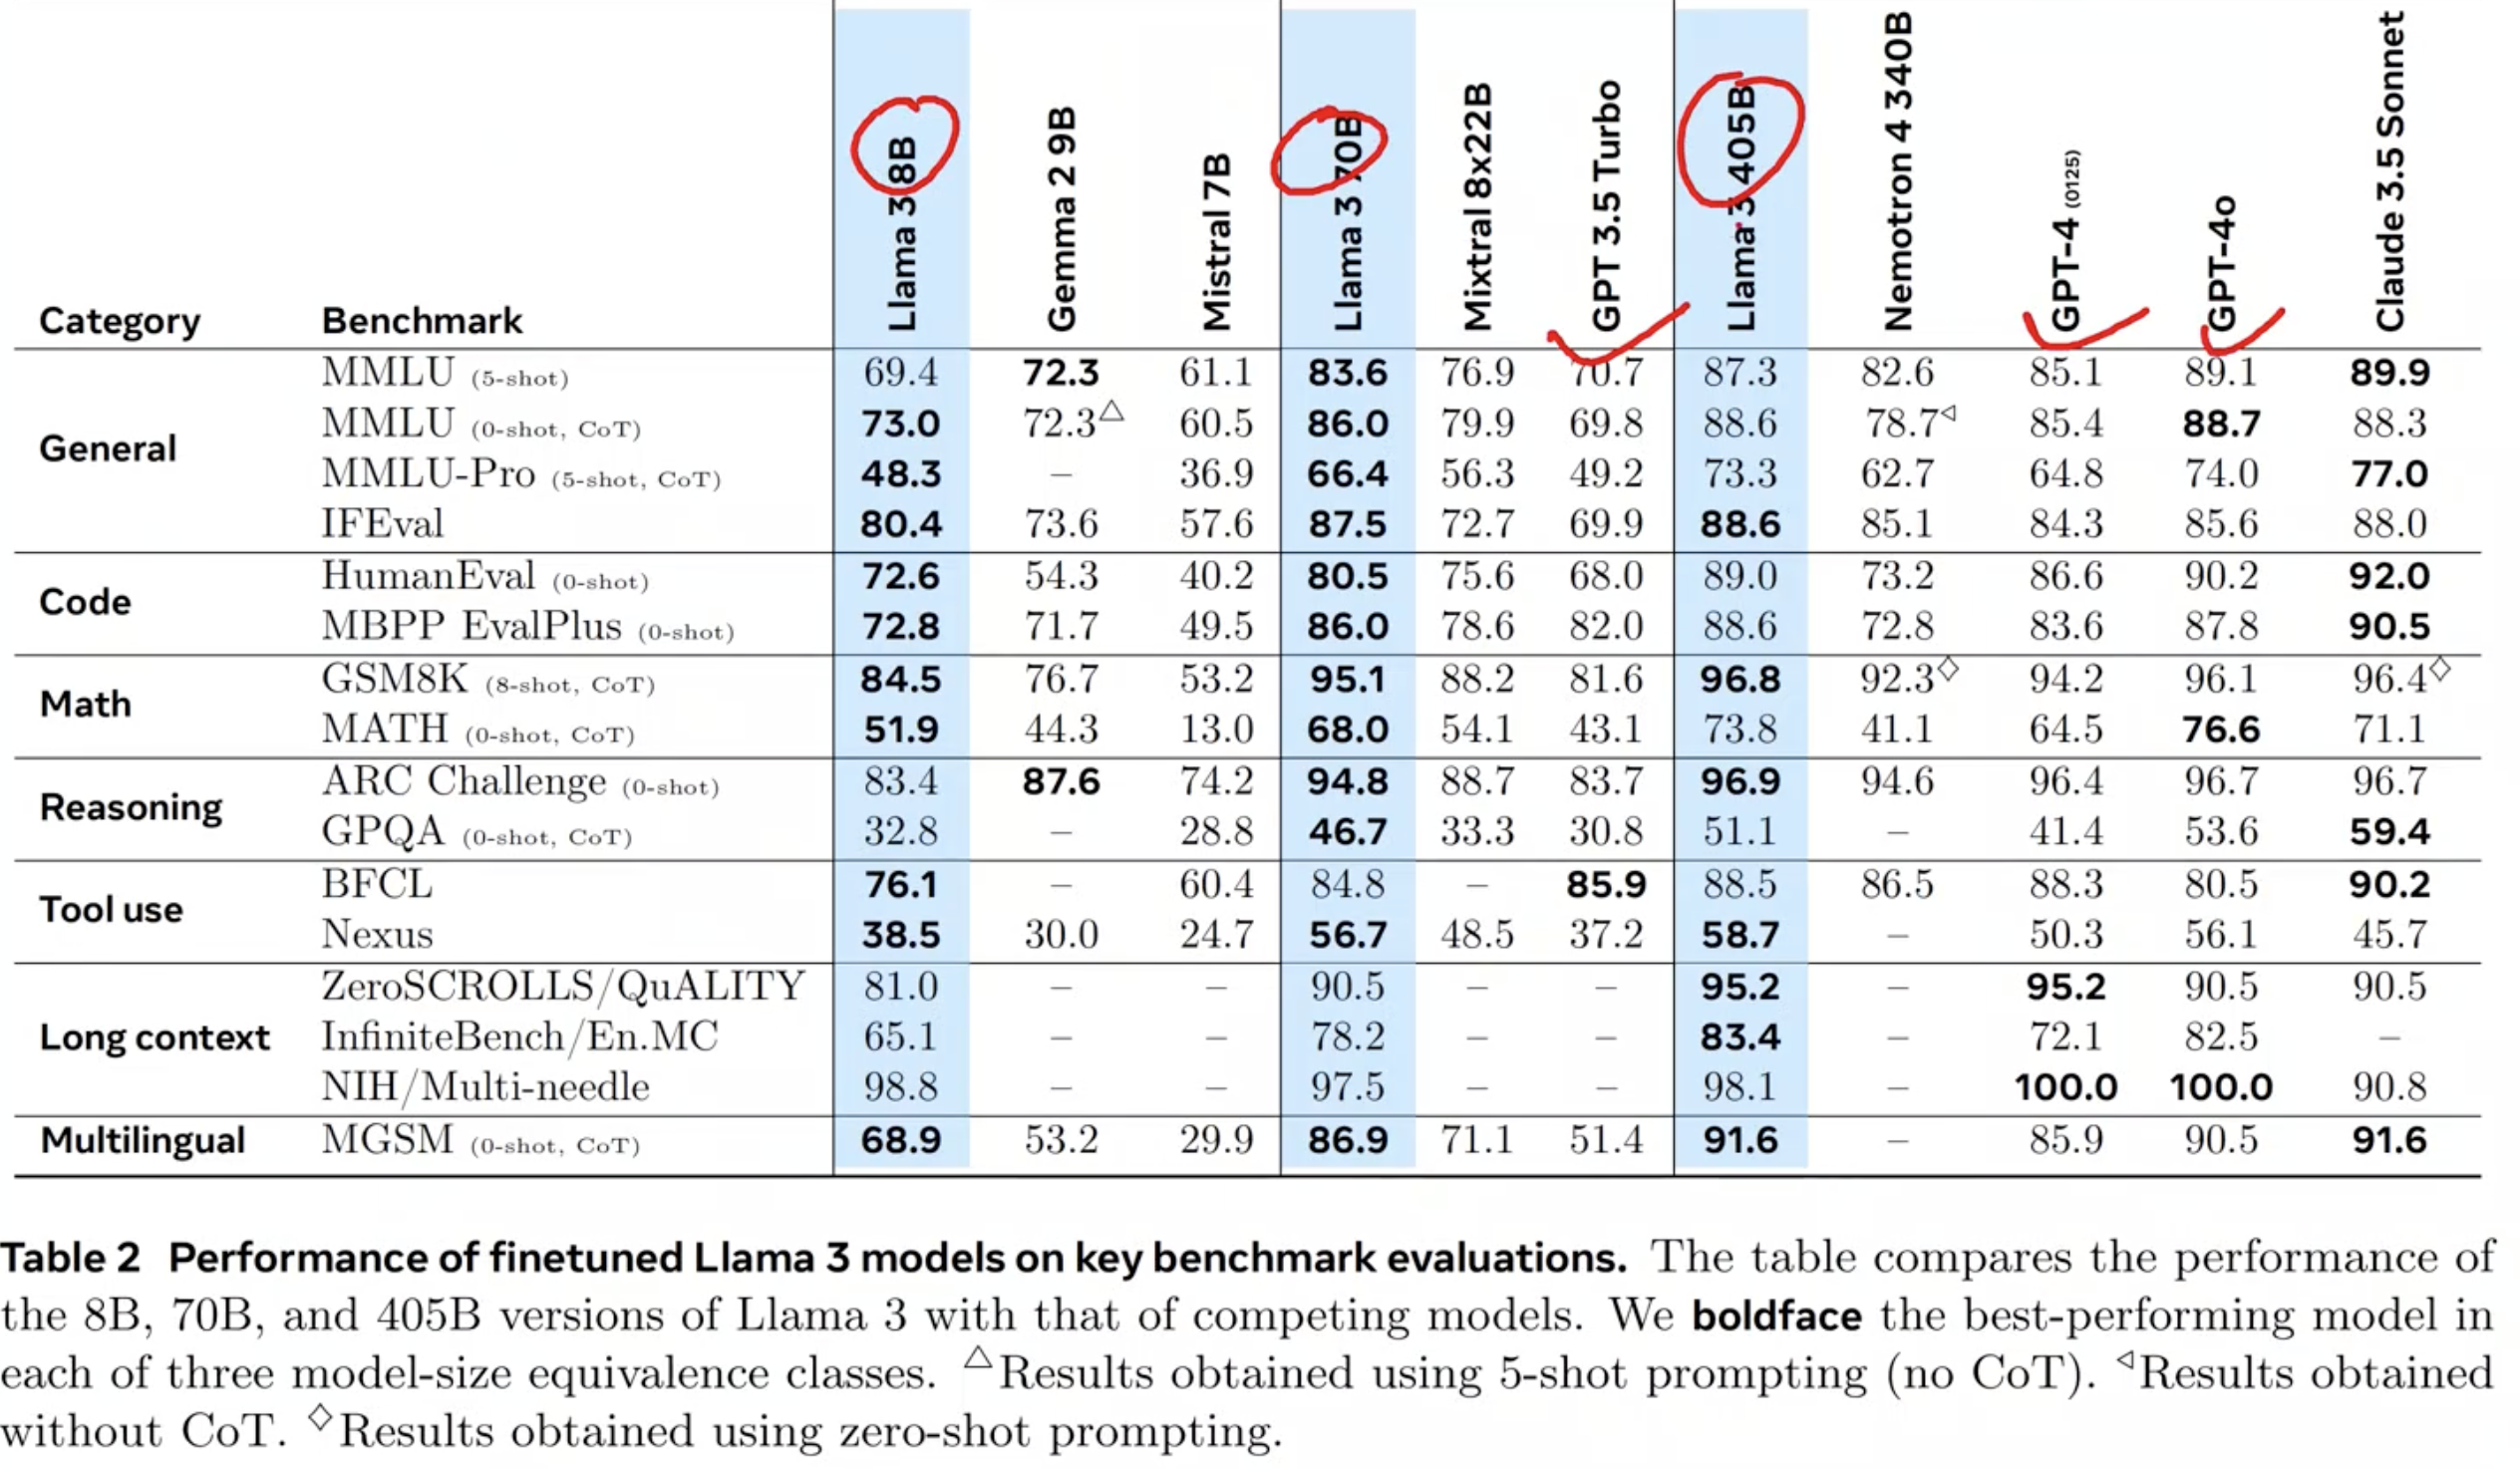

# step1    导入相关模块

In [1]:
from datasets import Dataset,load_dataset
from transformers import AutoTokenizer,AutoModelForCausalLM, \
    DataCollatorForSeq2Seq,TrainingArguments,Trainer

In [2]:
import transformers,torch
transformers.__version__, torch.__version__

('4.46.3', '2.2.2')

In [3]:
import warnings 
warnings.filterwarnings('ignore')

# Step2 加载数据集

In [4]:
import os
data_dir = os.path.expanduser("~/datasets/alpaca-gpt4-data-zh")

ds = load_dataset(path=data_dir,split="train")
ds

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 48818
})

In [5]:
ds[:2]

{'instruction': ['保持健康的三个提示。', '三原色是什么？'],
 'input': ['', ''],
 'output': ['以下是保持健康的三个提示：\n\n1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。\n\n2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。\n\n3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时的睡眠。良好的睡眠有助于减轻压力，促进身体恢复，并提高注意力和记忆力。',
  '三原色通常指的是红色、绿色和蓝色（RGB）。它们是通过加色混合原理创建色彩的三种基础颜色。在以发光为基础的显示设备中（如电视、计算机显示器、智能手机和平板电脑显示屏）, 三原色可混合产生大量色彩。其中红色和绿色可以混合生成黄色，红色和蓝色可以混合生成品红色，蓝色和绿色可以混合生成青色。当红色、绿色和蓝色按相等比例混合时，可以产生白色或灰色。\n\n此外，在印刷和绘画中，三原色指的是以颜料为基础的红、黄和蓝颜色（RYB）。这三种颜色用以通过减色混合原理来创建色彩。不过，三原色的具体定义并不唯一，不同的颜色系统可能会采用不同的三原色。']}

# Step3 数据集预处理

In [ ]:
model_path = os.path.expanduser("~/models/LLM-Research/Llama-3.2-3B-Instruct")

tokenizer = AutoTokenizer.from_pretrained(model_path)
tokenizer.pad_token = tokenizer.eos_token
tokenizer

PreTrainedTokenizerFast(name_or_path='/Users/daijunjie/models/LLM-Research/Llama-3.2-3B-Instruct', vocab_size=128000, model_max_length=131072, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|begin_of_text|>', 'eos_token': '<|eot_id|>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	128000: AddedToken("<|begin_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128001: AddedToken("<|end_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128002: AddedToken("<|reserved_special_token_0|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128003: AddedToken("<|reserved_special_token_1|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128004: AddedToken("<|finetune_right_pad_id|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128005: AddedToken("<|re

In [7]:
def process_func(item,tokenizer = None):
    MAX_LEN = 256
    instruction = tokenizer("\n".join( 
        ["Human: "+item["instruction"] ,item["input"]]  ).strip() + "\n\nAssistant: " 
                            ,add_special_tokens=False) 
    response = tokenizer(item["output"] + tokenizer.eos_token,add_special_tokens=False) 
    # 计算id 掩码 标签
    input_ids = instruction["input_ids"] + response["input_ids"]
    attention_mask = instruction["attention_mask"] + response["attention_mask"]
    # 输入部分遮盖掉，不是预测目标
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"]
    # 检查长度 过长就直接截断
    if len(input_ids) > MAX_LEN:
        input_ids = input_ids[:MAX_LEN]
        attention_mask = attention_mask[:MAX_LEN]
        labels = labels[:MAX_LEN]
    return {
        "input_ids":input_ids,
        "attention_mask":attention_mask,
        "labels":labels
    }

tokenized_ds = ds.map(process_func,
                      remove_columns = ds.column_names,
                      fn_kwargs={"tokenizer":tokenizer})
tokenized_ds

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 48818
})

In [8]:
tokenizer.decode(tokenized_ds[0]["input_ids"])

'Human: 保持健康的三个提示。\n\nAssistant: 以下是保持健康的三个提示：\n\n1. 保持身体活动。每天做适当的身体运动，如散步、跑步或游泳，能促进心血管健康，增强肌肉力量，并有助于减少体重。\n\n2. 均衡饮食。每天食用新鲜的蔬菜、水果、全谷物和脂肪含量低的蛋白质食物，避免高糖、高脂肪和加工食品，以保持健康的饮食习惯。\n\n3. 睡眠充足。睡眠对人体健康至关重要，成年人每天应保证 7-8 小时的睡眠。良好的睡眠有助于减轻压力，促进身体恢复，并提高注意力和记忆力。<|eot_id|>'

In [9]:
tokenizer.decode(list(filter(lambda x: x!=-100 , tokenized_ds[2]["labels"])))

'原子是物质的基本单位，它由三种基本粒子组成：质子、中子和电子。质子和中子形成原子核，位于原子中心，核外的电子围绕着原子核运动。\n\n原子结构具有层次性。原子核中，质子带正电，中子不带电（中性）。原子核非常小且致密，占据了原子总质量的绝大部分。电子带负电，通常围绕核运动，形成若干层次，称为壳层或电子层。电子数量与质子数量相等，使原子呈电中性。\n\n电子在每个壳层中都呈规律分布，并且不同壳层所能容纳的电子数也不同。在最里面的壳层一般只能容纳2个电子，其次一层最多可容纳8个电子，再往外的壳层可容纳的电子数逐层递增。\n\n原子核主要受到两种相互作用力的影响：强力和电磁力。强力的作用范围非常小，主要'

# Step4 模型创建

In [10]:
model = AutoModelForCausalLM.from_pretrained(model_path,
                                             low_cpu_mem_usage=True,
                                             torch_dtype=torch.float16,
                                             device_map="mps",
                                             )


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [11]:
model.device

device(type='mps', index=0)

In [12]:
sum(param.numel() for param in model.parameters())

3212749824

In [23]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 3072)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm

In [24]:
model.dtype

torch.float16

# LoRA
## PEFT Step1 配置文件

In [13]:
from peft import LoraConfig,TaskType,get_peft_model

In [ ]:
config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
)
config

LoraConfig(peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path=None, revision=None, task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, inference_mode=False, r=8, target_modules=None, lora_alpha=8, lora_dropout=0.0, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', loftq_config={}, use_dora=False, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False))

## PEFT Step2 模型创建

In [27]:
model = get_peft_model(model, config)
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): PeftModelForCausalLM(
      (base_model): LoraModel(
        (model): LlamaForCausalLM(
          (model): LlamaModel(
            (embed_tokens): Embedding(128256, 3072)
            (layers): ModuleList(
              (0-27): 28 x LlamaDecoderLayer(
                (self_attn): LlamaSdpaAttention(
                  (q_proj): lora.Linear(
                    (base_layer): Linear(in_features=3072, out_features=3072, bias=False)
                    (lora_dropout): ModuleDict(
                      (default): Identity()
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=3072, out_features=8, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): Linear(in_features=8, out_features=3072, bias=False)
                    )
                    (lora_embedding_A): ParameterDict()
                    (lora_embedding_B

In [26]:
model.print_trainable_parameters()

trainable params: 2,293,760 || all params: 3,215,043,584 || trainable%: 0.0713


# Step5 配置训练参数

In [ ]:
args = TrainingArguments(
    output_dir="./llama-7b",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    logging_steps=1,
    num_train_epochs=1,
    # 节省显存 但是需要重新计算前向传播
    gradient_checkpointing=True,
)

NameError: name 'TrainingArguments' is not defined

In [ ]:
trainer = Trainer(
    model=model,
    args = args,
    train_dataset = tokenized_ds.select(range(10)),
    data_collator = DataCollatorForSeq2Seq(tokenizer,padding=True),
)
trainer

In [37]:
trainer.train()

  0%|          | 0/5 [00:00<?, ?it/s]

{'loss': 1.9464, 'grad_norm': 0.5794314742088318, 'learning_rate': 4e-05, 'epoch': 0.2}
{'loss': 1.8282, 'grad_norm': 0.5841015577316284, 'learning_rate': 3e-05, 'epoch': 0.4}
{'loss': 1.7713, 'grad_norm': 0.6000431776046753, 'learning_rate': 2e-05, 'epoch': 0.6}
{'loss': 1.552, 'grad_norm': 0.6279403567314148, 'learning_rate': 1e-05, 'epoch': 0.8}
{'loss': 1.6837, 'grad_norm': 0.4854870140552521, 'learning_rate': 0.0, 'epoch': 1.0}
{'train_runtime': 20.11, 'train_samples_per_second': 0.497, 'train_steps_per_second': 0.249, 'train_loss': 1.75631902217865, 'epoch': 1.0}


TrainOutput(global_step=5, training_loss=1.75631902217865, metrics={'train_runtime': 20.11, 'train_samples_per_second': 0.497, 'train_steps_per_second': 0.249, 'total_flos': 35748233478144.0, 'train_loss': 1.75631902217865, 'epoch': 1.0})

# 模型推理

In [42]:
input = tokenizer("Human: {}\n{}".format("如何提高学习效率","").strip() + "\n\nAssistant: ",return_tensors="pt") \
    .to(model.device)

print(tokenizer.decode(model.generate(**input,do_sample=True,max_length=384)[0] , skip_special_tokens=True) )

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Human: 如何提高学习效率

Assistant: 以下是一些提高学习效率的建议：

1.  **设定目标**：明确学习目标，设定具体的学习计划和时间表，避免漫无目的的学习。
2.  **创造有利的学习环境**：选择适合学习的地点和时间，减少干扰，例如在 library 或 quiet area。
3.  **使用有效的学习方法**：尝试不同的学习方法，如重复、回忆、分析和概括等，找到适合自己的方法。
4.  **利用记忆技巧**：使用记忆技巧，如联想、图像记忆、重复等，帮助记忆和理解学习内容。
5.  **进行有效的复习**：定期复习学习内容，巩固记忆和理解，避免一次性学习。
6.  **利用技术**：使用学习应用、在线资源、电子书籍等技术，提高学习效率和效率。
7.  **保持健康和充足的睡眠**：确保身体和脑部得到充足的休息和睡眠，提高学习效率和记忆力。
8.  **避免分心**：减少分心的时间，例如使用手机、浏览社交媒体等，提高学习效率和专注度。
9.  **寻求帮助**：寻求帮助和支持，例如与老师、导师或学习小组讨论，提高学习效率和理解度。
10. **评估和调整**：定期评估学习效果，调整学习方法和策略，提高学习效率和效率。
